### Modellvergleich Machine Learning

In [ ]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression
Validiere Modell: Decision Tree
Validiere Modell: Random Forest
Validiere Modell: Gradient Boosting
Validiere Modell: XGBoost
Validiere Modell: LightGBM
Validiere Modell: SVC
Validiere Modell: k-Nearest Neighbors
Validiere Modell: MLP Classifier
Validiere Modell: Gaussian Naive Bayes
Validiere Modell: Linear Discriminant Analysis
Validiere Modell: Quadratic Discriminant Analysis
Validiere Modell: Bagging Classifier
Validiere Modell: Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
Logistic Regression,1.000 ± 0.000,0.868 ± 0.085,0.868 ± 0.086,0.874 ± 0.082,0.865 ± 0.111,0.894 ± 0.099,0.953 ± 0.044,0.967 ± 0.028,0.094 ± 0.046,0.325 ± 0.250
SVC,0.984 ± 0.014,0.853 ± 0.080,0.857 ± 0.079,0.851 ± 0.084,0.805 ± 0.128,0.921 ± 0.097,0.951 ± 0.045,0.964 ± 0.033,0.096 ± 0.034,0.307 ± 0.081
Extra Trees,1.000 ± 0.000,0.877 ± 0.077,0.882 ± 0.074,0.871 ± 0.085,0.810 ± 0.133,0.959 ± 0.069,0.947 ± 0.052,0.964 ± 0.033,0.119 ± 0.022,0.390 ± 0.051
MLP Classifier,1.000 ± 0.000,0.849 ± 0.085,0.850 ± 0.085,0.854 ± 0.084,0.838 ± 0.118,0.883 ± 0.098,0.932 ± 0.054,0.950 ± 0.041,0.117 ± 0.058,0.459 ± 0.348
Random Forest,1.000 ± 0.000,0.833 ± 0.085,0.837 ± 0.083,0.830 ± 0.092,0.787 ± 0.144,0.899 ± 0.096,0.921 ± 0.059,0.945 ± 0.039,0.130 ± 0.024,0.415 ± 0.055
k-Nearest Neighbors,0.917 ± 0.024,0.803 ± 0.089,0.805 ± 0.089,0.803 ± 0.097,0.775 ± 0.150,0.859 ± 0.110,0.901 ± 0.070,0.902 ± 0.060,0.132 ± 0.039,0.504 ± 0.344
XGBoost,1.000 ± 0.000,0.804 ± 0.089,0.805 ± 0.091,0.809 ± 0.087,0.790 ± 0.133,0.853 ± 0.115,0.900 ± 0.071,0.932 ± 0.049,0.138 ± 0.053,0.430 ± 0.157
LightGBM,0.999 ± 0.003,0.779 ± 0.094,0.779 ± 0.094,0.783 ± 0.098,0.770 ± 0.155,0.822 ± 0.107,0.890 ± 0.067,0.922 ± 0.047,0.145 ± 0.046,0.441 ± 0.123
Gaussian Naive Bayes,0.860 ± 0.027,0.820 ± 0.084,0.827 ± 0.080,0.802 ± 0.104,0.720 ± 0.155,0.935 ± 0.082,0.878 ± 0.075,0.907 ± 0.061,0.174 ± 0.080,2.027 ± 1.061
Gradient Boosting,1.000 ± 0.000,0.773 ± 0.111,0.772 ± 0.114,0.789 ± 0.100,0.792 ± 0.131,0.810 ± 0.140,0.851 ± 0.105,0.880 ± 0.102,0.210 ± 0.107,1.535 ± 1.066


## Korrelationsmatrix

Gefundene Cluster mit ≥2 Features:
Cluster 7 (2 Features):
  ['cmj_Ecc_peak_PW', 'cmj_Ecc_peak_Vel']

Cluster 8 (2 Features):
  ['cmj_FT_CT', 'cmj_RSI_Mod']

Cluster 11 (2 Features):
  ['INV_cmj_ Limb_stifness', 'UNINV_cmj_Limb_stifness']

Cluster 22 (2 Features):
  ['INV_slcmj_Con_Imp', 'INV_slcmj_Con_Peak_Vel']

Cluster 27 (4 Features):
  ['INV_slcmj_Ecc_decel_IMP', 'INV_slcmj_Ecc_mean_PW_w_kg', 'INV_slcmj_Ecc_peak_PW', 'INV_slcmj_Ecc_peak_Vel']

Cluster 29 (2 Features):
  ['INV_slcmj_Ecc_mean_force', 'UNINV_slcmj_Ecc_mean_force']

Cluster 31 (2 Features):
  ['INV_slcmj_FT_CT', 'INV_slcmj_RSI_Mod']

Cluster 38 (2 Features):
  ['UNINV_slcmj_Con_Imp', 'UNINV_slcmj_Con_Peak_Vel']

Cluster 43 (4 Features):
  ['UNINV_slcmj_Ecc_decel_IMP', 'UNINV_slcmj_Ecc_mean_PW_w_kg', 'UNINV_slcmj_Ecc_peak_PW', 'UNINV_slcmj_Ecc_peak_Vel']

Cluster 46 (2 Features):
  ['UNINV_slcmj_FT_CT', 'UNINV_slcmj_RSI_Mod']



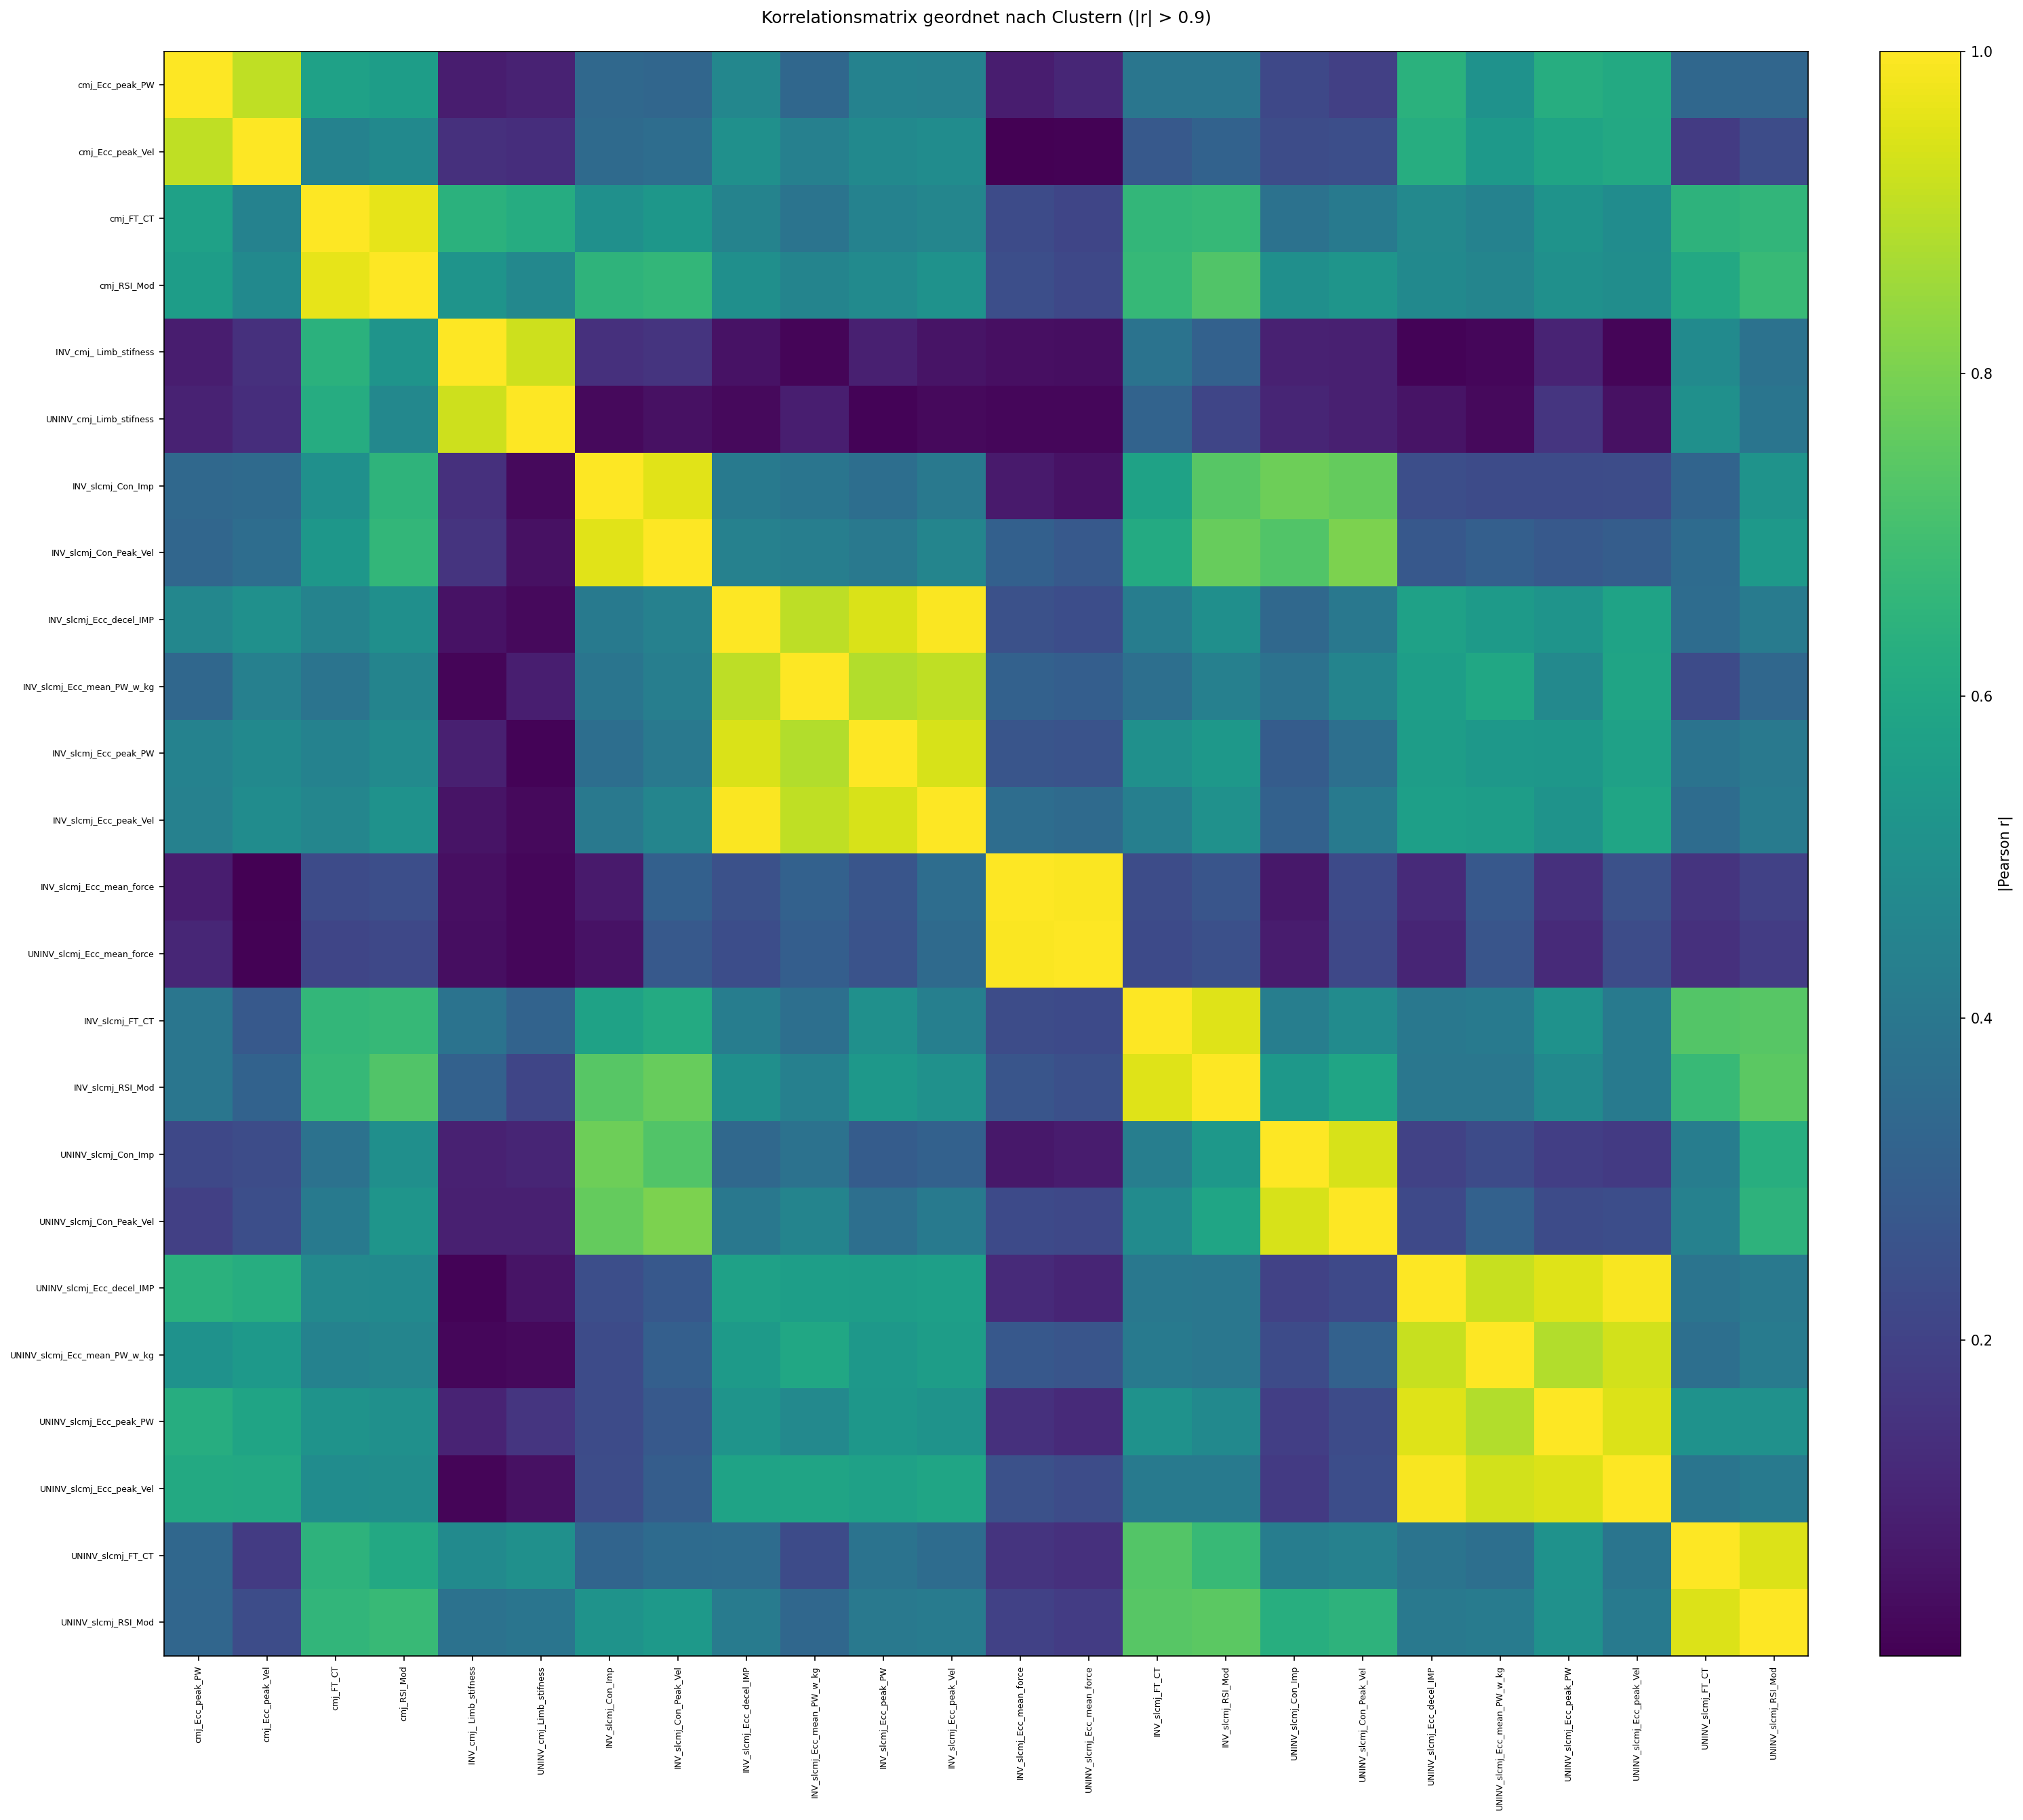

,cmj_Ecc_peak_PW,cmj_Ecc_peak_Vel,cmj_FT_CT,cmj_RSI_Mod,INV_cmj_ Limb_stifness,UNINV_cmj_Limb_stifness,INV_slcmj_Con_Imp,INV_slcmj_Con_Peak_Vel,INV_slcmj_Ecc_decel_IMP,INV_slcmj_Ecc_mean_PW_w_kg,INV_slcmj_Ecc_peak_PW,INV_slcmj_Ecc_peak_Vel,INV_slcmj_Ecc_mean_force,UNINV_slcmj_Ecc_mean_force,INV_slcmj_FT_CT,INV_slcmj_RSI_Mod,UNINV_slcmj_Con_Imp,UNINV_slcmj_Con_Peak_Vel,UNINV_slcmj_Ecc_decel_IMP,UNINV_slcmj_Ecc_mean_PW_w_kg,UNINV_slcmj_Ecc_peak_PW,UNINV_slcmj_Ecc_peak_Vel,UNINV_slcmj_FT_CT,UNINV_slcmj_RSI_Mod
cmj_Ecc_peak_PW,1.000000,0.904725,0.574245,0.559449,0.082895,0.097719,0.340876,0.331140,0.466011,0.336105,0.447102,0.441967,0.085874,0.112284,0.396891,0.396805,0.222004,0.194429,0.639684,0.511903,0.626544,0.608812,0.337771,0.334238
cmj_Ecc_peak_Vel,0.904725,1.000000,0.446858,0.475674,0.140940,0.135230,0.348118,0.358861,0.502939,0.438940,0.475162,0.489279,0.004378,0.011539,0.283552,0.318916,0.235869,0.245204,0.622935,0.541401,0.584412,0.606613,0.175532,0.234452
cmj_FT_CT,0.574245,0.446858,1.000000,0.961188,0.640962,0.620151,0.504794,0.531995,0.448628,0.386373,0.447059,0.459461,0.230951,0.211502,0.664112,0.669984,0.378004,0.409552,0.474514,0.445657,0.516710,0.487687,0.648956,0.661076
cmj_RSI_Mod,0.559449,0.475674,0.961188,1.000000,0.520399,0.469883,0.651865,0.664362,0.501997,0.454461,0.480303,0.512664,0.242942,0.220279,0.669460,0.728162,0.498577,0.524307,0.478349,0.457349,0.505546,0.492190,0.604768,0.674703
INV_cmj_ Limb_stifness,0.082895,0.140940,0.640962,0.520399,1.000000,0.924003,0.142120,0.155678,0.052674,0.018426,0.090529,0.056864,0.046602,0.041981,0.382281,0.313664,0.095605,0.090776,0.012211,0.022303,0.103338,0.016235,0.478946,0.379875
UNINV_cmj_Limb_stifness,0.097719,0.135230,0.620151,0.469883,0.924003,1.000000,0.030541,0.047522,0.027820,0.089341,0.012741,0.028756,0.022217,0.023272,0.320993,0.211174,0.109358,0.091636,0.055316,0.030903,0.157070,0.049924,0.502381,0.390222
INV_slcmj_Con_Imp,0.340876,0.348118,0.504794,0.651865,0.142120,0.030541,1.000000,0.956112,0.414496,0.391083,0.364407,0.406146,0.078053,0.053206,0.576438,0.742812,0.781751,0.763950,0.245218,0.229997,0.231457,0.235644,0.324904,0.516234
INV_slcmj_Con_Peak_Vel,0.331140,0.358861,0.531995,0.664362,0.155678,0.047522,0.956112,1.000000,0.440180,0.431591,0.406878,0.458825,0.309039,0.282851,0.611797,0.767034,0.728501,0.802872,0.277801,0.307395,0.282486,0.298634,0.352743,0.540870
INV_slcmj_Ecc_decel_IMP,0.466011,0.502939,0.448628,0.501997,0.052674,0.027820,0.414496,0.440180,1.000000,0.902173,0.942638,0.992777,0.252364,0.239523,0.425444,0.501300,0.340008,0.401670,0.572226,0.547591,0.519895,0.583716,0.357673,0.417876
INV_slcmj_Ecc_mean_PW_w_kg,0.336105,0.438940,0.386373,0.454461,0.018426,0.089341,0.391083,0.431591,0.902173,1.000000,0.884434,0.906037,0.312452,0.303484,0.366641,0.437753,0.378471,0.451694,0.563504,0.598292,0.474721,0.586084,0.233300,0.335615


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import HTML, display

# ─── 1) Pfad zur Datei ────────────────────────────────────────────────────────────
# Passe den Pfad an, falls nötig:
data_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx"

# ─── 2) Daten einlesen ────────────────────────────────────────────────────────────
df = pd.read_excel(data_path)

# ─── 3) Numerische Features extrahieren (Ziel und Geschlecht entfernen) ────────
exclude_cols = ["Verletzungsstatus"]
X = df.drop(columns=exclude_cols)

# ─── 4) Absolute Korrelationsmatrix berechnen ─────────────────────────────────────
corr = X.corr().abs()

# ─── 5) Connected Components Clustering (|r| > 0.9), ohne Selbst-Korrelation ──────
threshold = 0.90
features = corr.columns.tolist()
visited = set()
clusters = {}

for feat in features:
    if feat not in visited:
        queue = deque([feat])
        cluster = []
        while queue:
            current = queue.popleft()
            if current not in visited:
                visited.add(current)
                cluster.append(current)
                # Nur echte Nachbarn (nicht das Feature selbst)
                neighbors = [
                    nbr for nbr in corr.columns
                    if nbr != current and corr.loc[current, nbr] > threshold
                ]
                for nbr in neighbors:
                    if nbr not in visited:
                        queue.append(nbr)
        clusters[len(clusters)] = cluster

# ─── 6) Nur Cluster mit ≥2 Features behalten ───────────────────────────────────────
clusters = {i: cl for i, cl in clusters.items() if len(cl) > 1}

# ─── 7) Cluster ausgeben ──────────────────────────────────────────────────────────
print("Gefundene Cluster mit ≥2 Features:")
for idx, feat_list in clusters.items():
    print(f"Cluster {idx+1} ({len(feat_list)} Features):")
    print(f"  {feat_list}\n")

# ─── 8) Heatmap plotten (groß und hochauflösend) ──────────────────────────────────
order = [f for cl in clusters.values() for f in cl]
ordered_corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(20, 18), dpi=150)
im = ax.imshow(ordered_corr.values, aspect='auto')
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, fontsize=6)
ax.set_yticklabels(order, fontsize=6)
plt.title("Korrelationsmatrix geordnet nach Clustern (|r| > 0.9)", pad=20)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="|Pearson r|")
plt.tight_layout()
plt.show()

# ─── 9) Scrollbare HTML-Tabelle ───────────────────────────────────────────────────
html = (
    '<div style="height:700px; overflow:auto; border:1px solid #ccc;">'
    + ordered_corr.to_html()
    + '</div>'
)
display(HTML(html))


## SHAP-Werte berechnen mittels CV und globaler Plot 

In [6]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -1513.8248435941944 Max: 1978.5812696895284 Mean: 0.015597308498158914
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_slcmj_Con_duration                                             +1.129101        9.186987
LSI_peak torque_QUAD                                               -0.011993        0.660172
UNINV_peak torque_HAM                                              -0.003155        0.602595
UNINV_slcmj_Ecc_peak_force                                         +0.007608        0.553818
UNINV_peak torque_QUAD                                             -0.003577        0.513056
INV_peak torque_HAM                                                -0.005435        0.494615
INV_slcmj_Jump_height                                              -0.001149        0.38664

## SHAP Kontrolle

In [7]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 5.551e-17
Mittlere Abweichung : 2.220e-17
Median Abweichung   : 0.000e+00

P_SHAP=0.561350 | P_Modell=0.561350 | Δ=+0.00e+00
P_SHAP=0.991316 | P_Modell=0.991316 | Δ=+0.00e+00
P_SHAP=0.319314 | P_Modell=0.319314 | Δ=+5.55e-17
P_SHAP=0.997156 | P_Modell=0.997156 | Δ=+0.00e+00
P_SHAP=0.125943 | P_Modell=0.125943 | Δ=+5.55e-17


## Globaler SHAP Plot

→ Globaler Diverging Bar-Plot: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\SHAP\global_diverging_bar.png


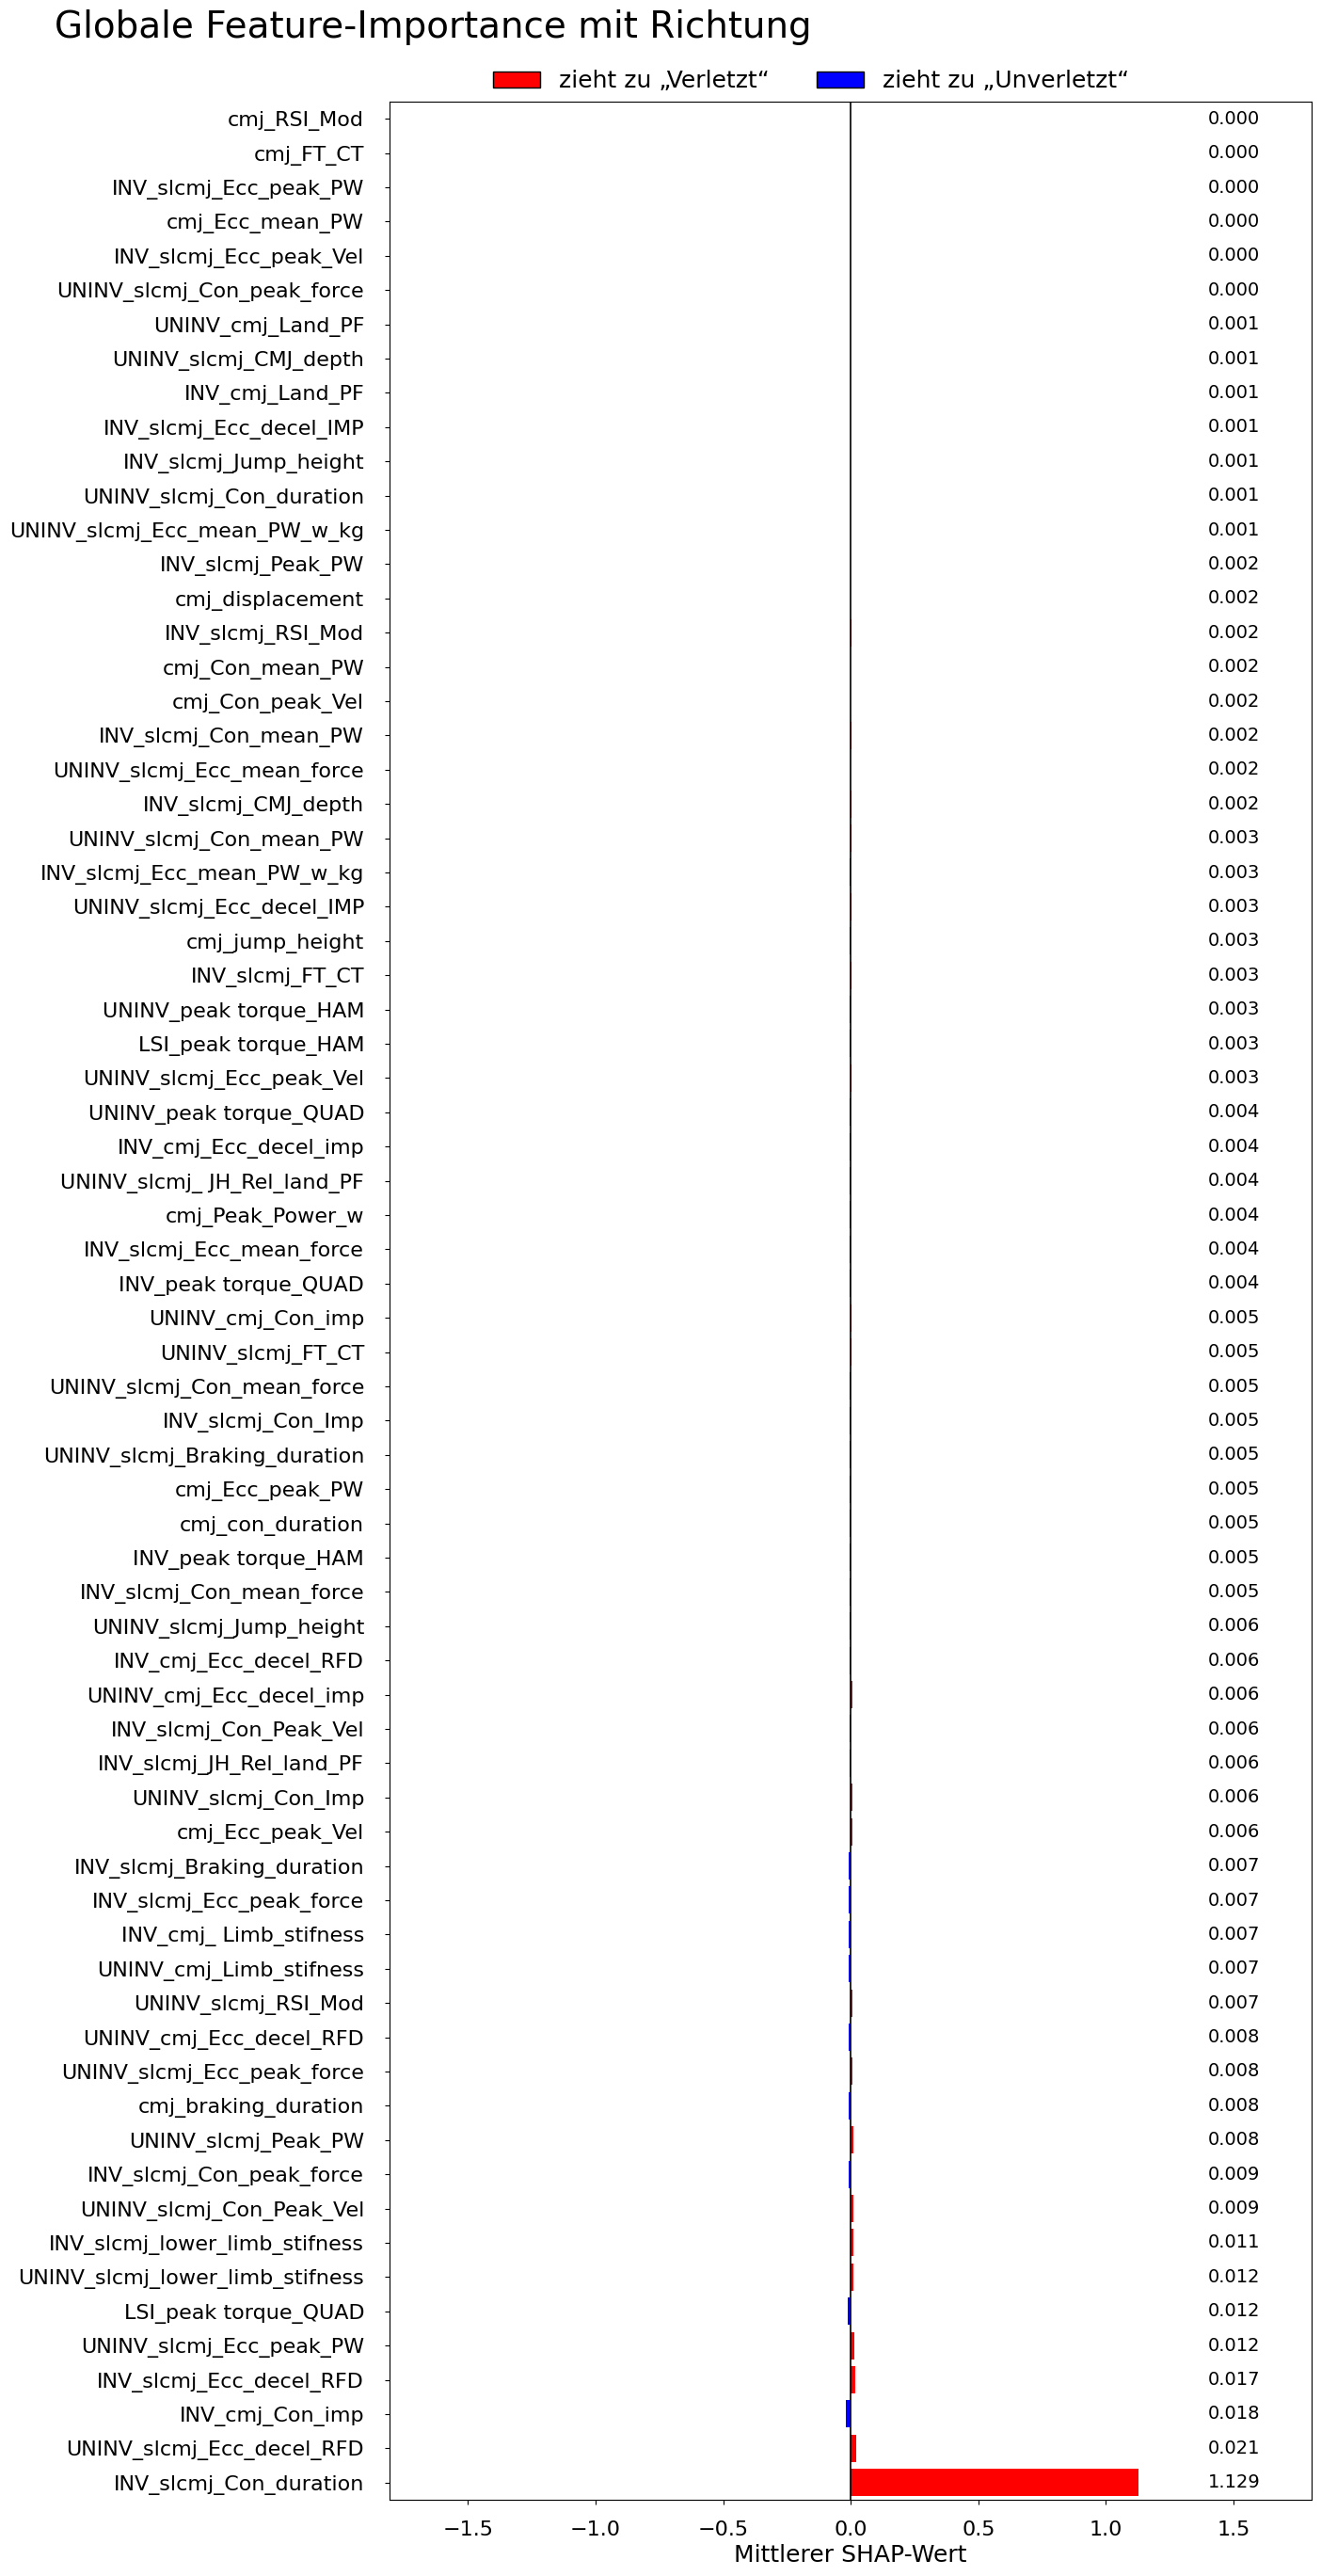

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\SHAP"

def plot_global_diverging_bar(
    features, 
    shap_stack, 
    output_dir, 
    title="Globale Feature-Importance mit Richtung",
    dpi=200
):
    """
    Zeichnet einen Diverging Bar-Plot:
      - rote Balken → höhere P(Verletzt),
      - blaue Balken → höhere P(Unverletzt).
    Ganz rechts außerhalb der Balken werden die absoluten mittleren SHAP-Werte
    angezeigt. Überschrift und Legende im Kopfbereich, Plot unten bündig.
    """
    # 1) Mittelwerte berechnen und sortieren
    mean_shap = np.mean(shap_stack, axis=0)
    idx_sort  = np.argsort(np.abs(mean_shap))[::-1]
    feat_sorted      = [features[i] for i in idx_sort]
    mean_shap_sorted = mean_shap[idx_sort]
    abs_sorted       = np.abs(mean_shap_sorted)
    colors           = ['red' if v>=0 else 'blue' for v in mean_shap_sorted]

    # 2) Puffer & Limits
    max_abs = abs_sorted.max()
    margin  = max_abs * 0.6

    # 3) Figur bauen
    fig_h = max(10, len(feat_sorted) * 0.4)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    # Überschrift im Kopfbereich, zentriert und größer
    fig.suptitle(title, fontsize=28, y=0.965, ha='right')

    # 4) Legende ebenfalls im Kopfbereich, zentriert unter dem Titel
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(
        handles=legend_elements,
        fontsize=18,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.95),
        frameon=False
    )

    # 5) Balken zeichnen
    ax.barh(feat_sorted, mean_shap_sorted, color=colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # 6) Achsen & Limits
    ax.set_xlabel("Mittlerer SHAP-Wert", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)
    ax.set_xlim(-max_abs - margin, max_abs + margin)

    # 7) Zahlen ganz rechts
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_sorted):
        ax.text(
            x_text,
            i,
            f"{val:.3f}",
            va='center',
            ha='left',
            fontsize=14
        )

    # 8) Plot unten bündig anschließen
    ax.set_ylim(-0.5, len(feat_sorted)-0.5)
    ax.margins(y=0)

    # 9) Layout: Platz oben für Suptitle + Legend, bündig unten
    plt.subplots_adjust(top=0.93, bottom=0.02, left=0.18, right=0.88)

    # 10) Speichern & Anzeigen
    out = os.path.join(output_dir, "global_diverging_bar.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Globaler Diverging Bar-Plot: {out}")
    plt.show()

# Aufruf
plot_global_diverging_bar(
    features=features, 
    shap_stack=shap_stack, 
    output_dir=shap_output_dir
)

## Cluster (Korrelation) und SHAP für Featurereduktion

In [9]:


import pandas as pd
from collections import deque
from IPython.display import display, HTML

# 1) Pfad und SHAP-Daten wie gehabt
data_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx"

# Falls noch nicht berechnet:
signed_mean_shap = pd.Series(np.mean(shap_stack, axis=0), index=features)
mean_abs_shap    = pd.Series(np.mean(np.abs(shap_stack), axis=0), index=features)

# 2) Daten einlesen
df = pd.read_excel(data_path)
features_all = [c for c in df.columns if c not in ["Verletzungsstatus"]]

# 3) Korrelationsmatrix
corr = df[features_all].corr().abs()

# 4) Clustering (|r|>0.9)
threshold = 0.9
visited = set()
clusters = {}
for feat in features_all:
    if feat not in visited:
        queue = deque([feat])
        cluster = []
        while queue:
            cur = queue.popleft()
            if cur not in visited:
                visited.add(cur)
                cluster.append(cur)
                neighbors = [
                    nbr for nbr in features_all
                    if nbr != cur and corr.loc[cur, nbr] > threshold and nbr not in visited
                ]
                queue.extend(neighbors)
        if len(cluster) > 1:
            clusters[len(clusters) + 1] = cluster

# 5) Cluster-/SHAP-Tabelle bauen
rows = []
for cid, feats in clusters.items():
    for f in feats:
        rows.append({
            "cluster_id":   cid,
            "cluster_size": len(feats),
            "feature":      f,
            "signed_mean":  signed_mean_shap.loc[f],
            "mean_abs_shap": mean_abs_shap.loc[f]
        })

cluster_shap_df = (
    pd.DataFrame(rows)
      .sort_values(["cluster_id", "signed_mean"], ascending=[True, False])  # <- Sortierung nach signed_mean
      .reset_index(drop=True)
)

# 6) Tabelle anzeigen
display(cluster_shap_df)




,cluster_id,cluster_size,feature,signed_mean,mean_abs_shap
0,1,2,cmj_Ecc_peak_Vel,0.006480,0.124908
1,1,2,cmj_Ecc_peak_PW,-0.005345,0.205826
2,2,2,cmj_RSI_Mod,-0.000085,0.284424
3,2,2,cmj_FT_CT,-0.000148,0.198129
4,3,2,INV_cmj_ Limb_stifness,-0.007292,0.131628
5,3,2,UNINV_cmj_Limb_stifness,-0.007296,0.068432
6,4,2,INV_slcmj_Con_Imp,-0.004923,0.346672
7,4,2,INV_slcmj_Con_Peak_Vel,-0.005743,0.250672
8,5,4,INV_slcmj_Ecc_decel_IMP,0.000884,0.207462
9,5,4,INV_slcmj_Ecc_peak_Vel,0.000444,0.244048


## Features to remove extrahieren

In [15]:


# ─── Save & Remove Feature Auswahl (basierend auf signed_mean) ─────────────────────
cutoff = 0.003
to_save, to_remove = [], []

# Hilfsspalte für Betrag der signed_means
cluster_shap_df["abs_signed_mean"] = cluster_shap_df["signed_mean"].abs()

# 1. Direkt alle Features >= cutoff sichern
save_mask = cluster_shap_df["abs_signed_mean"] > cutoff
direct_save = cluster_shap_df.loc[save_mask, "feature"].tolist()
to_save.extend(direct_save)

# 2. Clusterweise für den Rest (<= cutoff)
for cid, feats in cluster_shap_df.groupby("cluster_id"):
    feats_low = feats[feats["abs_signed_mean"] <= cutoff]
    if feats_low.empty:
        continue
    
    # bestes Feature im Cluster sichern (das mit höchstem abs_signed_mean)
    top_row = feats_low.iloc[0]
    top_feat = top_row["feature"]
    if top_feat not in to_save:
        to_save.append(top_feat)
    
    # Rest vorläufig in to_remove
    for f in feats_low["feature"]:
        if f != top_feat and f not in to_save:
            to_remove.append(f)
            if f.startswith("INV"):
                partner = f.replace("INV", "UNINV", 1)
            elif f.startswith("UNINV"):
                partner = f.replace("UNINV", "INV", 1)
            else:
                partner = None
            if partner and partner not in to_save:
                to_remove.append(partner)

# ─── Neue Logik: Paare immer gemeinsam behandeln ─────────────────────────────────
final_remove = []
for f in to_remove:
    if f.startswith("INV"):
        partner = f.replace("INV", "UNINV", 1)
    elif f.startswith("UNINV"):
        partner = f.replace("UNINV", "INV", 1)
    else:
        partner = None

    if partner:
        if partner in to_save:
            continue

        shap_f_arr = cluster_shap_df.loc[cluster_shap_df["feature"] == f, "abs_signed_mean"].values
        shap_f = shap_f_arr[0] if len(shap_f_arr) > 0 else 0.0
        shap_p_arr = cluster_shap_df.loc[cluster_shap_df["feature"] == partner, "abs_signed_mean"].values
        shap_partner = shap_p_arr[0] if len(shap_p_arr) > 0 else 0.0

        # Wenn einer >= cutoff → beide behalten
        if shap_f > cutoff or shap_partner > cutoff:
            continue

        # Sonst beide entfernen
        if f not in to_save:
            final_remove.append(f)
        if partner not in to_save:
            final_remove.append(partner)
    else:
        if f not in to_save:
            final_remove.append(f)

# Doppelte entfernen, Reihenfolge beibehalten
to_save = list(dict.fromkeys(to_save))
to_remove = list(dict.fromkeys(final_remove))

# ─── Ergebnisse printen ──────────────────────────────────────────────────────────
print("to_save = [")
for f in to_save:
    shap_val = cluster_shap_df.loc[cluster_shap_df["feature"] == f, "abs_signed_mean"].values
    val = shap_val[0] if len(shap_val) > 0 else None
    print(f'    "{f}",   # |signed_mean|={val:.6f}' if val is not None else f'    "{f}",')
print("]\n")

print("to_remove = [")
for f in to_remove:
    shap_val = cluster_shap_df.loc[cluster_shap_df["feature"] == f, "abs_signed_mean"].values
    val = shap_val[0] if len(shap_val) > 0 else None
    print(f'    "{f}",   # |signed_mean|={val:.6f}' if val is not None else f'    "{f}",')
print("]")

# ─── Saubere Python-Liste für to_remove ──────────────────────────────────────────
print("\nSaubere Python-Liste (to_remove_unique):\n")
print("to_remove_unique = [")
for f in to_remove:
    print(f'    "{f}",')
print("]")


to_save = [
    "cmj_Ecc_peak_Vel",   # |signed_mean|=0.006480
    "cmj_Ecc_peak_PW",   # |signed_mean|=0.005345
    "INV_cmj_ Limb_stifness",   # |signed_mean|=0.007292
    "UNINV_cmj_Limb_stifness",   # |signed_mean|=0.007296
    "INV_slcmj_Con_Imp",   # |signed_mean|=0.004923
    "INV_slcmj_Con_Peak_Vel",   # |signed_mean|=0.005743
    "INV_slcmj_Ecc_mean_force",   # |signed_mean|=0.004119
    "INV_slcmj_FT_CT",   # |signed_mean|=0.003148
    "UNINV_slcmj_Con_Peak_Vel",   # |signed_mean|=0.008881
    "UNINV_slcmj_Con_Imp",   # |signed_mean|=0.006133
    "UNINV_slcmj_Ecc_peak_PW",   # |signed_mean|=0.012335
    "UNINV_slcmj_Ecc_peak_Vel",   # |signed_mean|=0.003390
    "UNINV_slcmj_RSI_Mod",   # |signed_mean|=0.007446
    "UNINV_slcmj_FT_CT",   # |signed_mean|=0.004635
    "cmj_RSI_Mod",   # |signed_mean|=0.000085
    "INV_slcmj_Ecc_decel_IMP",   # |signed_mean|=0.000884
    "UNINV_slcmj_Ecc_mean_force",   # |signed_mean|=0.002312
    "INV_slcmj_RSI_Mod",   # |signed_mean|=0.001927
 

## Feature entfernen

In [16]:
import pandas as pd

# ─── 1) Ursprüngliche Liste der zu entfernenden Features ────────────────────────
to_remove_unique = [
    "cmj_FT_CT",
    "INV_slcmj_Ecc_mean_PW_w_kg",
    "UNINV_slcmj_Ecc_mean_PW_w_kg",
]

# ─── 2) Duplikate in Echtzeit erkennen und melden ────────────────────────────────
duplicates = [x for x in set(to_remove) if to_remove.count(x) > 1]
if duplicates:
    print("Gefundene Duplikate in to_remove-Liste:")
    for d in duplicates:
        print("  -", d)

# ─── 3) Liste deduplizieren, Reihenfolge bleibt erhalten ─────────────────────────
to_remove_unique = list(dict.fromkeys(to_remove))
print(f"\nVerwendete (einmalige) Liste mit {len(to_remove_unique)} Features zum Entfernen.")

# ─── 4) Excel-Datei einlesen und Spalten löschen ─────────────────────────────────
input_path  = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx"
output_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"

df = pd.read_excel(input_path)

# Prüfen, welche Features tatsächlich vorhanden sind
missing = [f for f in to_remove_unique if f not in df.columns]
if missing:
    print("\nDiese Features fehlen in der Tabelle und werden übersprungen:")
    for m in missing:
        print("  -", m)

# Drop nur existierender Spalten
to_drop = [f for f in to_remove_unique if f in df.columns]
df_clean = df.drop(columns=to_drop)

# ─── 5) Gesäuberte Tabelle speichern ─────────────────────────────────────────────
df_clean.to_excel(output_path, index=False)
print(f"\nFertig! Reduzierte Tabelle gespeichert unter:\n{output_path}")



Verwendete (einmalige) Liste mit 3 Features zum Entfernen.

Fertig! Reduzierte Tabelle gespeichert unter:
K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx


## Metriken nach reduziertem Datensatz (Redundanz vermieden)

In [17]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
Logistic Regression,1.000 ± 0.000,0.864 ± 0.082,0.864 ± 0.083,0.870 ± 0.080,0.858 ± 0.112,0.894 ± 0.099,0.951 ± 0.046,0.966 ± 0.029,0.096 ± 0.046,0.331 ± 0.252


## SHAP mit reduzierten Features

In [18]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -1464.4768608458514 Max: 2083.902138521673 Mean: 0.027534353559229546
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_slcmj_Con_duration                                             +1.880317        9.727898
LSI_peak torque_QUAD                                               -0.011556        0.648445
UNINV_peak torque_HAM                                              -0.003189        0.603401
UNINV_slcmj_Ecc_peak_force                                         +0.007748        0.571137
UNINV_peak torque_QUAD                                             -0.003507        0.511318
INV_peak torque_HAM                                                -0.005526        0.496138
INV_slcmj_Jump_height                                              -0.001213        0.402113

## Globaler SHAP Plot mit reduzierten Features

→ Globaler Diverging Bar-Plot: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\SHAP\global_diverging_bar.png


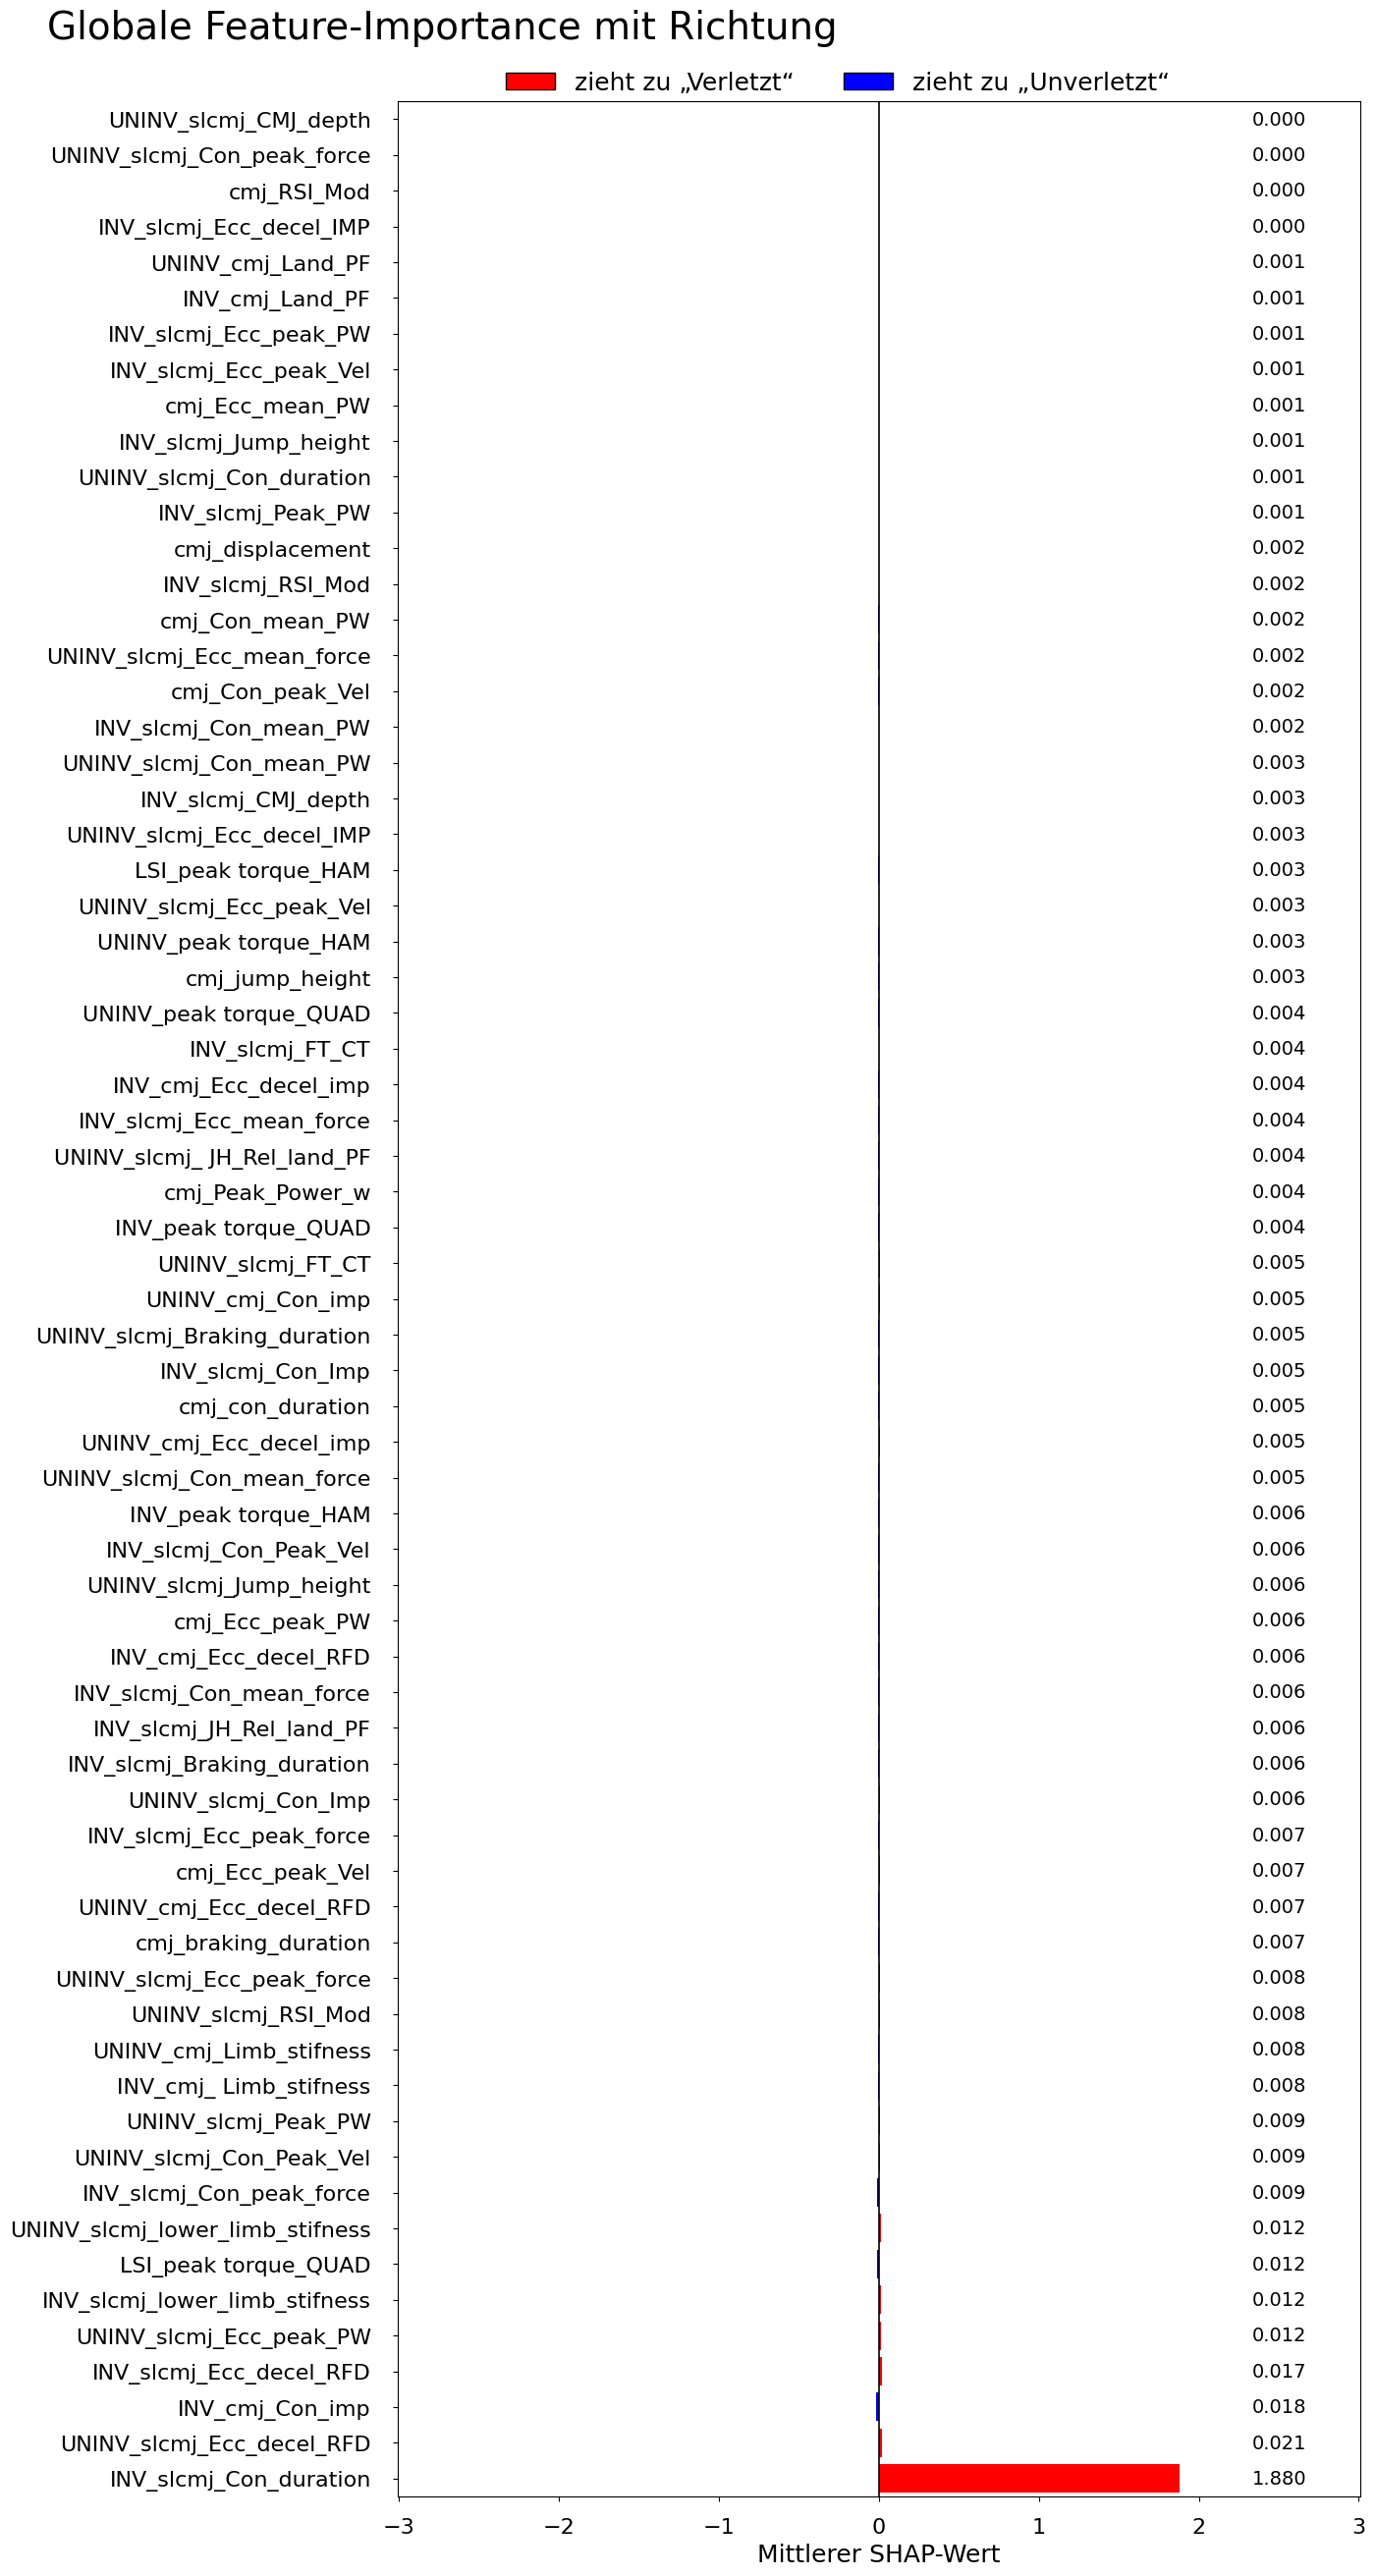

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\SHAP"

def plot_global_diverging_bar(
    features, 
    shap_stack, 
    output_dir, 
    title="Globale Feature-Importance mit Richtung",
    dpi=200
):
    """
    Zeichnet einen Diverging Bar-Plot:
      - rote Balken → höhere P(Verletzt),
      - blaue Balken → höhere P(Unverletzt).
    Ganz rechts außerhalb der Balken werden die absoluten mittleren SHAP-Werte
    angezeigt. Überschrift und Legende im Kopfbereich, Plot unten bündig.
    """
    # 1) Mittelwerte berechnen und sortieren
    mean_shap = np.mean(shap_stack, axis=0)
    idx_sort  = np.argsort(np.abs(mean_shap))[::-1]
    feat_sorted      = [features[i] for i in idx_sort]
    mean_shap_sorted = mean_shap[idx_sort]
    abs_sorted       = np.abs(mean_shap_sorted)
    colors           = ['red' if v>=0 else 'blue' for v in mean_shap_sorted]

    # 2) Puffer & Limits
    max_abs = abs_sorted.max()
    margin  = max_abs * 0.6

    # 3) Figur bauen
    fig_h = max(10, len(feat_sorted) * 0.4)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    # Überschrift im Kopfbereich, zentriert und größer
    fig.suptitle(title, fontsize=28, y=0.965, ha='right')

    # 4) Legende ebenfalls im Kopfbereich, zentriert unter dem Titel
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(
        handles=legend_elements,
        fontsize=18,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.95),
        frameon=False
    )

    # 5) Balken zeichnen
    ax.barh(feat_sorted, mean_shap_sorted, color=colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # 6) Achsen & Limits
    ax.set_xlabel("Mittlerer SHAP-Wert", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)
    ax.set_xlim(-max_abs - margin, max_abs + margin)

    # 7) Zahlen ganz rechts
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_sorted):
        ax.text(
            x_text,
            i,
            f"{val:.3f}",
            va='center',
            ha='left',
            fontsize=14
        )

    # 8) Plot unten bündig anschließen
    ax.set_ylim(-0.5, len(feat_sorted)-0.5)
    ax.margins(y=0)

    # 9) Layout: Platz oben für Suptitle + Legend, bündig unten
    plt.subplots_adjust(top=0.93, bottom=0.02, left=0.18, right=0.88)

    # 10) Speichern & Anzeigen
    out = os.path.join(output_dir, "global_diverging_bar.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Globaler Diverging Bar-Plot: {out}")
    plt.show()

# Aufruf
plot_global_diverging_bar(
    features=features, 
    shap_stack=shap_stack, 
    output_dir=shap_output_dir
)



## 10% Cut-off

In [20]:

import numpy as np
import pandas as pd

# ─── 1) Mittlere signed SHAP-Werte ─────────────────────────────────────────────
signed_mean_shaps = np.mean(shap_stack, axis=0)
abs_signed_mean = pd.Series(np.abs(signed_mean_shaps), index=features)

# ─── 2) Aufsteigend sortieren & kumulative Summe ───────────────────────────────
sorted_shap = abs_signed_mean.sort_values()
cumsum      = sorted_shap.cumsum()
threshold   = 0.10 * sorted_shap.sum()

# ─── 3) Untere 10% als erste Kandidaten ────────────────────────────────────────
base_to_remove = sorted_shap[cumsum <= threshold].index.tolist()

print(f"10%-Cutoff-Schwelle (basierend auf |signed_mean|): {threshold:.4f}")
print(f"Kandidaten für Entfernung (vor Paarlogik): {len(base_to_remove)} Features")

# ─── 4) Funktion: Paare konsistent behandeln ───────────────────────────────────
def enforce_pair_logic(base_remove, shap_series, cutoff=0.003):
    final_remove = []
    seen = set()

    def get_partner(name: str):
        if name.startswith("INV"):
            return name.replace("INV", "UNINV", 1)
        elif name.startswith("UNINV"):
            return name.replace("UNINV", "INV", 1)
        else:
            return None

    for f in base_remove:
        if f in seen:
            continue

        partner = get_partner(f)

        if not partner:
            # Single-Feature ohne INV/UNINV
            final_remove.append(f)
            seen.add(f)
            continue

        if partner in shap_series.index:
            shap_f = shap_series.get(f, 0.0)
            shap_p = shap_series.get(partner, 0.0)

            if partner in base_remove:
                # Beide schon in Liste → konsistent entfernen
                final_remove.extend([f, partner])
                seen.update([f, partner])
            else:
                if shap_p <= cutoff:
                    # Partner ist schwach → auch entfernen
                    final_remove.extend([f, partner])
                    seen.update([f, partner])
                else:
                    # Partner stark genug → beide behalten
                    continue
        else:
            # Partner nicht im Datensatz → wie Single behandeln
            final_remove.append(f)
            seen.add(f)

    return list(dict.fromkeys(final_remove))  # Reihenfolge & eindeutige Werte

# ─── 5) Anwenden ───────────────────────────────────────────────────────────────
to_remove = enforce_pair_logic(base_to_remove, abs_signed_mean, cutoff=0.003)

# ─── 6) Ausgabe ────────────────────────────────────────────────────────────────
print("\nFinale to_remove-Liste (paar-konsistent, basierend auf |signed_mean|):\n")
print("to_remove = [")
for f in to_remove:
    val = abs_signed_mean.get(f, None)
    if val is not None:
        print(f'    "{f}",   # |signed_mean|={val:.6f}')
    else:
        print(f'    "{f}",')
print("]")

# ─── 7) Rohe Python-Liste für Weiterverarbeitung ───────────────────────────────
print("\nSaubere Python-Liste (nur Feature-Namen):\n")
print("to_remove = [")
for f in to_remove:
    print(f'    "{f}",')
print("]")

10%-Cutoff-Schwelle (basierend auf |signed_mean|): 0.2228
Kandidaten für Entfernung (vor Paarlogik): 56 Features

Finale to_remove-Liste (paar-konsistent, basierend auf |signed_mean|):

to_remove = [
    "UNINV_slcmj_CMJ_depth",   # |signed_mean|=0.000125
    "INV_slcmj_CMJ_depth",   # |signed_mean|=0.002627
    "cmj_RSI_Mod",   # |signed_mean|=0.000234
    "INV_slcmj_Ecc_decel_IMP",   # |signed_mean|=0.000296
    "UNINV_slcmj_Ecc_decel_IMP",   # |signed_mean|=0.002653
    "UNINV_cmj_Land_PF",   # |signed_mean|=0.000566
    "INV_cmj_Land_PF",   # |signed_mean|=0.000610
    "INV_slcmj_Ecc_peak_Vel",   # |signed_mean|=0.000739
    "UNINV_slcmj_Ecc_peak_Vel",   # |signed_mean|=0.002847
    "cmj_Ecc_mean_PW",   # |signed_mean|=0.000800
    "INV_slcmj_Jump_height",   # |signed_mean|=0.001213
    "UNINV_slcmj_Jump_height",   # |signed_mean|=0.005708
    "cmj_displacement",   # |signed_mean|=0.001656
    "INV_slcmj_RSI_Mod",   # |signed_mean|=0.001920
    "UNINV_slcmj_RSI_Mod",   # |signed_me

## Endgültiger Datensatz nach 10% Cut-off

In [21]:
import pandas as pd

# ─── 1) Ursprüngliche Liste der zu entfernenden Features ────────────────────────
to_remove = [
    "UNINV_slcmj_CMJ_depth",
    "INV_slcmj_CMJ_depth",
    "cmj_RSI_Mod",
    "INV_slcmj_Ecc_decel_IMP",
    "UNINV_slcmj_Ecc_decel_IMP",
    "UNINV_cmj_Land_PF",
    "INV_cmj_Land_PF",
    "INV_slcmj_Ecc_peak_Vel",
    "UNINV_slcmj_Ecc_peak_Vel",
    "cmj_Ecc_mean_PW",
    "INV_slcmj_Jump_height",
    "UNINV_slcmj_Jump_height",
    "cmj_displacement",
    "INV_slcmj_RSI_Mod",
    "UNINV_slcmj_RSI_Mod",
    "cmj_Con_mean_PW",
    "UNINV_slcmj_Ecc_mean_force",
    "INV_slcmj_Ecc_mean_force",
    "cmj_Con_peak_Vel",
    "INV_slcmj_Con_mean_PW",
    "UNINV_slcmj_Con_mean_PW",
    "LSI_peak torque_HAM",
    "UNINV_peak torque_HAM",
    "INV_peak torque_HAM",
    "cmj_jump_height",
    "UNINV_peak torque_QUAD",
    "INV_peak torque_QUAD",
    "INV_slcmj_FT_CT",
    "UNINV_slcmj_FT_CT",
    "INV_cmj_Ecc_decel_imp",
    "UNINV_cmj_Ecc_decel_imp",
    "UNINV_slcmj_ JH_Rel_land_PF",
    "cmj_Peak_Power_w",
    "UNINV_slcmj_Braking_duration",
    "INV_slcmj_Braking_duration",
    "INV_slcmj_Con_Imp",
    "UNINV_slcmj_Con_Imp",
    "cmj_con_duration",
    "UNINV_slcmj_Con_mean_force",
    "INV_slcmj_Con_mean_force",
    "cmj_Ecc_peak_PW",
    "INV_cmj_Ecc_decel_RFD",
    "UNINV_cmj_Ecc_decel_RFD",
    "INV_slcmj_JH_Rel_land_PF",
    "INV_slcmj_Ecc_peak_force",
    "UNINV_slcmj_Ecc_peak_force",
    "cmj_Ecc_peak_Vel",
    "cmj_braking_duration",
    "UNINV_cmj_Limb_stifness",
    "INV_cmj_ Limb_stifness",
]


# ─── 2) Duplikate in Echtzeit erkennen und melden ────────────────────────────────
duplicates = [x for x in set(to_remove) if to_remove.count(x) > 1]
if duplicates:
    print("Gefundene Duplikate in to_remove-Liste:")
    for d in duplicates:
        print("  -", d)

# ─── 3) Liste deduplizieren, Reihenfolge bleibt erhalten ─────────────────────────
to_remove_unique = list(dict.fromkeys(to_remove))
print(f"\nVerwendete (einmalige) Liste mit {len(to_remove_unique)} Features zum Entfernen.")

# ─── 4) Excel-Datei einlesen und Spalten löschen ─────────────────────────────────
input_path  = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"
output_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean_10.xlsx"

df = pd.read_excel(input_path)

# Prüfen, welche Features tatsächlich vorhanden sind
missing = [f for f in to_remove_unique if f not in df.columns]
if missing:
    print("\nDiese Features fehlen in der Tabelle und werden übersprungen:")
    for m in missing:
        print("  -", m)

# Drop nur existierender Spalten
to_drop = [f for f in to_remove_unique if f in df.columns]
df_clean = df.drop(columns=to_drop)

# ─── 5) Gesäuberte Tabelle speichern ─────────────────────────────────────────────
df_clean.to_excel(output_path, index=False)
print(f"\nFertig! Gesäuberte Tabelle gespeichert unter:\n{output_path}")



Verwendete (einmalige) Liste mit 50 Features zum Entfernen.

Fertig! Gesäuberte Tabelle gespeichert unter:
K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean_10.xlsx


## Metriken mit finalem Datensatz

In [22]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean_10.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
Logistic Regression,0.930 ± 0.022,0.857 ± 0.082,0.857 ± 0.083,0.864 ± 0.079,0.860 ± 0.116,0.883 ± 0.100,0.914 ± 0.076,0.931 ± 0.064,0.119 ± 0.055,0.417 ± 0.259


### Übereinstimmung der Header-Variablen vergleichen (Schnittmenge vs. Maestroni/Unsere Daten)...Rest nochmal manuell prüfen

In [67]:
import re
import pandas as pd
from rapidfuzz import fuzz, process

# ====== Parameter ======
big_path   = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Unsere_Daten\Basistabelle_ML_vkb_male_clean_10.xlsx"
small_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Basistabelle_Maestroni_ML.xlsx"
BIG_SHEET = 0
SMALL_SHEET = 0

FUZZY_THRESHOLD = 90     # Haupt-Schwelle für Rohtext-Fuzzy
CRITICAL_BAND   = (90, 94)  # „kritische“ Zone zur Nachprüfung (inklusive)
USE_FALLBACK_NORMALIZATION = True  # auf False setzen, wenn du GAR KEINE Normalisierung willst
FALLBACK_THRESHOLD = 88    # etwas toleranter für den Fallback

# ====== Hilfsfunktionen ======
def light_normalize(s: str) -> str:
    """Sanfte Normalisierung NUR für Fallback:
       - lower, trim
       - Umlaute vereinheitlichen
       - Mehrfachspaces zu einem Space
       - Einheiten in [..] entfernen
       - '-Mittelwert ...' hinten abschneiden
       (kein aggressives Synonym-Mapping!)
    """
    s0 = str(s).strip().lower().replace("ß", "ss")
    s1 = re.sub(r"\[.*?\]", "", s0)               # Einheiten weg
    s1 = re.sub(r"-\s*mittelwert\b.*$", "", s1)   # "-Mittelwert ..." weg
    s1 = re.sub(r"\s+", " ", s1)
    return s1

def fuzzy_match_list(query, choices, threshold):
    """Gibt bestes Match >= threshold zurück (name, score) oder (None, 0)."""
    best = process.extractOne(query, choices, scorer=fuzz.token_set_ratio)
    if best:
        cand, score, _ = best
        if score >= threshold:
            return cand, score
    return None, 0

# ====== Header lesen (nur lesen, nichts schreiben) ======
big_df   = pd.read_excel(big_path, sheet_name=BIG_SHEET, nrows=0)
small_df = pd.read_excel(small_path, sheet_name=SMALL_SHEET, nrows=0)

big_cols   = [str(c) for c in big_df.columns]
small_cols = [str(c) for c in small_df.columns]

big_set = set(big_cols)

# ====== 1) Exakte Rohtext-Matches ======
exact_matches = {}
pending = []
for s in small_cols:
    if s in big_set:
        exact_matches[s] = (s, 100)
    else:
        pending.append(s)

# ====== 2) Fuzzy auf Rohtext ======
fuzzy_matches = {}
critical_fuzzy = {}
still_unmatched = []

for s in pending:
    cand, score = fuzzy_match_list(s, big_cols, FUZZY_THRESHOLD)
    if cand:
        # in „kritischer Zone“ gesondert ausweisen
        if CRITICAL_BAND[0] <= score <= CRITICAL_BAND[1]:
            critical_fuzzy[s] = (cand, score)
        else:
            fuzzy_matches[s] = (cand, score)
    else:
        still_unmatched.append(s)

# ====== 3) Optionaler Fallback mit sanfter Normalisierung ======
fallback_matches = {}
if USE_FALLBACK_NORMALIZATION and still_unmatched:
    big_norm_map = {light_normalize(c): c for c in big_cols}
    big_norm_choices = list(big_norm_map.keys())

    for s in list(still_unmatched):  # Kopie, damit wir entfernen können
        s_norm = light_normalize(s)
        cand_norm, score = fuzzy_match_list(s_norm, big_norm_choices, FALLBACK_THRESHOLD)
        if cand_norm:
            fallback_matches[s] = (big_norm_map[cand_norm], score)
            still_unmatched.remove(s)

# ====== Bericht ======
all_matched = set(exact_matches) | set(fuzzy_matches) | set(critical_fuzzy) | set(fallback_matches)
unmatched = [c for c in small_cols if c not in all_matched]

print("\n=== Exact raw matches ===")
for k, (v, sc) in exact_matches.items():
    print(f"{k}\n→ {v} (score={sc})")

print("\n=== Fuzzy raw matches (>= threshold) ===")
for k, (v, sc) in sorted(fuzzy_matches.items(), key=lambda x: (-x[1][1], x[0])):
    print(f"{k}\n→ {v} (score={sc})")

print("\n=== Fuzzy raw matches (kritische Zone) ===")
for k, (v, sc) in sorted(critical_fuzzy.items(), key=lambda x: (-x[1][1], x[0])):
    print(f"{k}\n→ {v} (score={sc})  <-- BITTE prüfen")

if USE_FALLBACK_NORMALIZATION:
    print("\n=== Fallback (leicht normalisiert) ===")
    for k, (v, sc) in sorted(fallback_matches.items(), key=lambda x: (-x[1][1], x[0])):
        print(f"{k}\n→ {v} (score={sc}) [fallback]")

print("\n=== Unmatched ===")
for u in unmatched:
    print(u)

# Kurzstatistik
total = len([c for c in small_cols if c])
matched = len(all_matched)
print(f"\nTrefferquote: {matched}/{total} = {matched/total:.1%}")

# Optional: als Dict für Weiterverarbeitung
# mapping_small_to_big = {**{k:v for k,(v,_) in exact_matches.items()},
#                         **{k:v for k,(v,_) in fuzzy_matches.items()},
#                         **{k:v for k,(v,_) in critical_fuzzy.items()},
#                         **{k:v for k,(v,_) in fallback_matches.items()}}



=== Exact raw matches ===
Verletzungsstatus
→ Verletzungsstatus (score=100)
INV_ISO_Max Extension 
→ INV_ISO_Max Extension  (score=100)
UNINV_ISO_Max Extension 
→ UNINV_ISO_Max Extension  (score=100)
ISO_Drehmoment_Seitenunterschied Extension relativ
→ ISO_Drehmoment_Seitenunterschied Extension relativ (score=100)
INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s]
→ INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s] (score=100)
UNINV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s]
→ UNINV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s] (score=100)
INV_CMJ_uni_Av. propulsive force 
→ INV_CMJ_uni_Av. propulsive force  (score=100)
UNINV_CMJ_uni_Av. propulsive force 
→ UNINV_CMJ_uni_Av. propulsive force  (score=100)
INV_CMJ_uni_Peak braking force 
→ INV_CMJ_uni_Peak braking force  (score=100)
UNINV_CMJ_uni_Peak braking force 
→ UNINV_CMJ_uni_Peak braking force  (score=100)
INV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]
→ INV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW] (scor